**El objetivo global de este primer cuaderno es fabricar desde cero un conjunto de datos multimodal perfectamente sincronizado en el espacio y en el tiempo. El flujo de trabajo garantiza matemáticamente que cada dato meteorológico (temperatura, humedad, viento) registrado en una estación meteorológica canaria esté asociado a una imagen satelital multiespectral capturada exactamente ese mismo día y sobre esas mismas coordenadas.**

1. IMPORTAMOS LIBRERIAS NECESARIAS Y CREAMOS LAS CONSTANTES A USAR EN EL NOTEBOOK

En esta celda configuro el entorno de trabajo, cargo las librerías analíticas y espaciales, y defino las bases del proyecto: credenciales de las APIs, el marco temporal del estudio (2017-2026) y la arquitectura estructural de las imágenes (64x64 píxeles, 6 bandas espectrales).

  \* Importante: usaremos el almacenamiento en nuestro Drive de Google


In [1]:
# Librerías estándar y de terceros
import os
import time
import requests
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Librerías específicas de Google Colab y Earth Engine
from google.colab import auth, drive
import ee

# Constantes de autenticación y rutas
API_KEY = "eyJhbGciOiJIUzI1NiJ9.eyJzdWIiOiJqcmFtb3NtZW5kb3phM0BnbWFpbC5jb20iLCJq\
dGkiOiIyYTAyYWM0Ny1lZTZhLTQ3NDEtOWQ0Yi1mOTdmOGQ1OTIzZjIiLCJpc3MiOiJBRU1FVCIsImlh\
dCI6MTc4MTgxMTI5NSwidXNlcklkIjoiMmEwMmFjNDctZWU2YS00NzQxLTlkNGItZjk3ZjhkNTkyM2Yy\
Iiwicm9sZSI6IiJ9.0T8q8cfY4ebvgsrJ_xZhUoBbsOXWNvBuPdMCmtl-UX4"
BASE_URL_AEMET = "https://opendata.aemet.es/opendata/api"
PROYECTO_GCP = "tfm-bbdd-499813"

# Rutas de almacenamiento en Google Drive
RUTA_CARPETA_TFM = '/content/drive/MyDrive/TFM_Riesgo_Incendios_Canarias'
RUTA_CATALOGO = os.path.join(RUTA_CARPETA_TFM, "catalogo_estaciones_canarias.csv")
RUTA_DATASET = os.path.join(RUTA_CARPETA_TFM, "dataset_meteo_satelite.csv")
RUTA_TENSORES = os.path.join(RUTA_CARPETA_TFM, "tensores_satelite")

# Parámetros temporales y espaciales
ANIO_INICIO = 2017
ANIO_FIN = 2026
FECHA_INICIO_SAT = "2017-03-28"
FECHA_FIN_SAT = "2026-07-30"

# Parámetros de extracción de imágenes (Sentinel-2)
BANDAS = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
N_BANDAS = len(BANDAS)
TAMANO_PIXELES = 64
METROS_POR_PIXEL = 10
RADIO_METROS = (TAMANO_PIXELES * METROS_POR_PIXEL) / 2

# monto la unidad de Drive local y creo la carpeta base si no existe
drive.mount('/content/drive')
os.makedirs(RUTA_TENSORES, exist_ok=True)

Mounted at /content/drive


2. INICIALIZACIÓN DE SERVICIOS.

Ejecuto la autenticación del usuario que corre el cuaderno y levanto la conexión con los clústeres de cálculo de Google Earth Engine.

\* Para poder usar los datos de Google Earth Engine es necesario registrarse y rellenar un cuestionario sobre el uso de datos. Como el objetivo es académico, está permitido su uso de forma pública.

In [2]:
def inicializar_gee(proyecto: str) -> None:
    """
    Autentico la sesión del usuario y conecto con los servidores de Google Earth Engine.

    Parameters
    ----------
    proyecto: str
        Identificador del proyecto en Google Cloud.

    Returns
    -------
    None
        La función no devuelve ningún valor pero establece la conexión activa con la API.
    """
    try:
        print("solicitando credenciales a Google Colab...")
        auth.authenticate_user()

        print("vinculando credenciales con Earth Engine...")
        ee.Authenticate()
        ee.Initialize(project=proyecto)

        print("¡conexión completada con éxito!")
    except Exception as e:
        print(f"error al inicializar Google Earth Engine: {e}")

# ejecuto la conexión
inicializar_gee(PROYECTO_GCP)

solicitando credenciales a Google Colab...
vinculando credenciales con Earth Engine...
¡conexión completada con éxito!


3. EXTRACCIÓN DEL CATÁLOGO DE ESTACIONES METEO.

Me conecto a la API de AEMET para descargar el inventario nacional de estaciones. Filtro los datos para aislar únicamente las 58 estaciones operativas en el archipiélago canario y aplico una función matemática para transformar su georreferenciación sexagesimal a formato decimal estándar.


In [3]:
def convertir_coordenadas_aemet(coord_str: str) -> float:
    """
    Transformo las coordenadas sexagesimales concatenadas que devuelve la AEMET
    al formato decimal estándar necesario para cruzar con datos satelitales.

    Parameters
    ----------
    coord_str: str
        Cadena original con la coordenada sexagesimal (ej. '280523N').

    Returns
    -------
    float
        Coordenada decimal equivalente (negativa para Sur y Oeste).
        Devuelve None si el valor de entrada es nulo o inválido.

    Examples
    --------
    >>> convertir_coordenadas_aemet('280523N')
    28.089722
    >>> convertir_coordenadas_aemet('170641W')
    -17.111389
    """
    if pd.isna(coord_str):
        return None

    coord_str = str(coord_str).strip()
    direccion = coord_str[-1]
    numeros = coord_str[:-1]

    try:
        segundos = float(numeros[-2:])
        minutos = float(numeros[-4:-2])
        grados = float(numeros[:-4])

        decimal = grados + (minutos / 60) + (segundos / 3600)

        # aplico la corrección de signo geográfico
        if direccion in ['S', 'W']:
            decimal = -decimal

        return round(decimal, 6)
    except ValueError:
        return None

def extraer_catalogo_canarias() -> pd.DataFrame:
    """
    Extraigo el catálogo nacional de estaciones meteorológicas y filtro
    exclusivamente las ubicadas en el archipiélago canario.

    Returns
    -------
    pd.DataFrame
        Inventario limpio con variables de interés y coordenadas decimales.
    """

    endpoint = "/valores/climatologicos/inventarioestaciones/todasestaciones"
    headers = {"cache-control": "no-cache", "api_key": API_KEY}

    try:
        resp_inicial = requests.get(BASE_URL_AEMET + endpoint, headers=headers)
        resp_inicial.raise_for_status()
        datos_json = resp_inicial.json()

        if datos_json.get("estado") == 200:
            url_datos = datos_json.get("datos")
            resp_datos = requests.get(url_datos)
            resp_datos.raise_for_status()

            df_estaciones = pd.DataFrame(resp_datos.json())

            # aíslo las estaciones canarias por provincia
            provincias = ['STA. CRUZ DE TENERIFE', 'LAS PALMAS']
            df_canarias = df_estaciones[df_estaciones['provincia'].isin(provincias)].copy()

            columnas_interes = ['indicativo', 'nombre', 'provincia', 'altitud', 'latitud', 'longitud']
            df_canarias = df_canarias[columnas_interes]

            # estandarizo la georreferenciación
            df_canarias['latitud_dec'] = df_canarias['latitud'].apply(convertir_coordenadas_aemet)
            df_canarias['longitud_dec'] = df_canarias['longitud'].apply(convertir_coordenadas_aemet)

            return df_canarias.reset_index(drop=True)

        print(f"error en la API AEMET: {datos_json.get('descripcion')}")
        return pd.DataFrame()

    except requests.exceptions.RequestException as e:
        print(f"fallo en la conexión HTTP: {e}")
        return pd.DataFrame()

# extraigo y guardo el catálogo
catalogo_canarias = extraer_catalogo_canarias()
if not catalogo_canarias.empty:
    catalogo_canarias.to_csv(RUTA_CATALOGO, index=False, encoding='utf-8-sig')
    print(f"catálogo consolidado con {len(catalogo_canarias)} estaciones y guardado en Drive.")

catálogo consolidado con 58 estaciones y guardado en Drive.


4. LÓGICA DE SINCRONIZACIÓN Y CLIMA.

Defino las funciones individuales necesarias para el cruce de datos satelitales y meteo: Creo la función que interroga a Earth Engine para calcular el calendario exacto de sobrevuelos sobre una latitud/longitud concreta, y las funciones que descargan la meteorología anual de la AEMET en bloques semestrales para esquivar los límites y bloqueos del servidor estatal.

In [4]:
def calendario_por_estacion(lat: float, lon: float) -> list:
    """
    Interrogo a Earth Engine para obtener las fechas exactas de captura
    de Sentinel-2 sobre una coordenada puntual.

    Parameters
    ----------
    lat: float
        Latitud decimal de la estación.
    lon: float
        Longitud decimal de la estación.

    Preconditions
    -------------
    Las coordenadas deben ubicarse dentro de las franjas de captura del satélite en Canarias.

    Returns
    -------
    list
        Fechas de captura válidas en formato 'YYYY-MM-DD'.
    """
    punto_estacion = ee.Geometry.Point([lon, lat])

    coleccion_punto = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(punto_estacion)
        .filterDate(FECHA_INICIO_SAT, FECHA_FIN_SAT)
    )

    def extraer_fecha(imagen):
        fecha_formateada = imagen.date().format('YYYY-MM-dd')
        return ee.Feature(None, {'fecha': fecha_formateada})

    fechas_mapeadas = coleccion_punto.map(extraer_fecha)
    fechas_unicas = fechas_mapeadas.aggregate_array('fecha').distinct().sort()

    return fechas_unicas.getInfo()

def extraer_aemet_semestral(estacion: str, fecha_ini: str, fecha_fin: str) -> pd.DataFrame:
    """
    Descargo un bloque de medio año de registros meteorológicos de una estación
    meteorológica, para respetar los límites de saturación de la API de AEMET.

    Parameters
    ----------
    estacion: str
        Indicativo alfanumérico de la estación meteorológica.
    fecha_ini: str
        Fecha de inicio de la extracción en formato 'YYYY-MM-DDTHH:MM:SSUTC'.
    fecha_fin: str
        Fecha de finalización en formato 'YYYY-MM-DDTHH:MM:SSUTC'.

    Returns
    -------
    pd.DataFrame
        Tabla con los datos climatológicos brutos del periodo solicitado.
    """

    endpoint = f"/valores/climatologicos/diarios/datos/fechaini/{fecha_ini}/fechafin/{fecha_fin}/estacion/{estacion}"
    headers = {"cache-control": "no-cache", "api_key": API_KEY}

    try:
        resp = requests.get(BASE_URL_AEMET + endpoint, headers=headers)
        if resp.status_code == 200:
            datos_json = resp.json()
            if datos_json.get("estado") == 200:
                url_datos = datos_json.get("datos")
                datos_reales = requests.get(url_datos).json()
                return pd.DataFrame(datos_reales)
    except Exception:
        pass
    return pd.DataFrame()

def extraer_anio_completo(estacion: str, anio: int) -> pd.DataFrame:
    """
    Concateno dos descargas semestrales para reconstruir el año climático completo
    de la estación de interés.

    Parameters
    ----------
    estacion: str
        Indicativo alfanumérico de la estación meteorológica.
    anio: int
        Año natural a consultar.

    Returns
    -------
    pd.DataFrame
        Datos climatológicos crudos correspondientes a los 365 días del año.
    """
    df_anio = pd.DataFrame()
    df_s1 = extraer_aemet_semestral(estacion, f"{anio}-01-01T00:00:00UTC", f"{anio}-06-30T23:59:59UTC")
    time.sleep(0.3)  # mitigación de throttling
    df_s2 = extraer_aemet_semestral(estacion, f"{anio}-07-01T00:00:00UTC", f"{anio}-12-31T23:59:59UTC")
    time.sleep(0.3)

    if not df_s1.empty:
        df_anio = pd.concat([df_anio, df_s1], ignore_index=True)
    if not df_s2.empty:
        df_anio = pd.concat([df_anio, df_s2], ignore_index=True)

    return df_anio

def limpiar_aemet_reducido(df_crudo: pd.DataFrame) -> pd.DataFrame:
    """
    Normalizo los formatos de fecha y corrijo los separadores decimales europeos
    para las 3 variables climáticas predictoras.

    Parameters
    ----------
    df_crudo: pd.DataFrame
        Tabla original con los datos extraídos de la API sin formatear.

    Returns
    -------
    pd.DataFrame
        Tabla limpia con las métricas transformadas a tipos numéricos (float/int).
    """
    df_limpio = df_crudo.copy()
    columnas_num = ['tmax', 'hrMedia', 'velmedia']

    for col in columnas_num:
        if col in df_limpio.columns:
            df_limpio[col] = df_limpio[col].astype(str).str.replace(',', '.')
            df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

    if 'fecha' in df_limpio.columns:
        df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha']).dt.strftime('%Y-%m-%d')

    return df_limpio

5. AQUI ENSAMBLAMOS EL DATASET CON DATOS METEOROLÓGICOS.

Itero sobre las 58 estaciones, descargo el calendario satelital específico de cada una y extraigo su histórico climático completo. Acto seguido, me quedo ÚNICAMENTE con los registro meteorológicos de la estación que tengan asociado un sobrevuelo del satélite Sentinel-2, exportando el resultado limpio a un archivo CSV.

In [5]:
# Leo el catálogo base generado en la celda anterior
df_estaciones = pd.read_csv(RUTA_CATALOGO)
dataset_final = []

for index, fila in tqdm(df_estaciones.iterrows(), total=len(df_estaciones), desc="procesando estaciones"):
    indicativo = fila['indicativo']
    lat = fila['latitud_dec']
    lon = fila['longitud_dec']

    # obtengo el calendario satelital específico de esta estación
    fechas_satelite = calendario_por_estacion(lat, lon)
    if not fechas_satelite:
        continue

    df_meteo_estacion = pd.DataFrame()

    # descargo todo su histórico meteorológico
    for anio in range(ANIO_INICIO, ANIO_FIN + 1):
        df_anio = extraer_anio_completo(indicativo, anio)
        if not df_anio.empty:
            df_meteo_estacion = pd.concat([df_meteo_estacion, df_anio], ignore_index=True)

    if df_meteo_estacion.empty:
        continue

    df_meteo_limpio = limpiar_aemet_reducido(df_meteo_estacion)

    # filtro el clima quedándome únicamente con los días que tienen imagen espacial
    df_filtrado = df_meteo_limpio[df_meteo_limpio['fecha'].isin(fechas_satelite)].copy()

    if not df_filtrado.empty:
        df_filtrado['indicativo'] = indicativo
        df_filtrado['nombre'] = fila['nombre']
        df_filtrado['provincia'] = fila['provincia']
        df_filtrado['latitud_dec'] = lat
        df_filtrado['longitud_dec'] = lon

        columnas_finales = [
            'indicativo', 'nombre', 'provincia', 'latitud_dec', 'longitud_dec',
            'fecha', 'tmax', 'hrMedia', 'velmedia'
        ]

        # garantizo la estructura aunque falte alguna métrica
        for col in columnas_finales:
            if col not in df_filtrado.columns:
                df_filtrado[col] = pd.NA

        dataset_final.append(df_filtrado[columnas_finales])

if dataset_final:
    df_dataset_maestro = pd.concat(dataset_final, ignore_index=True)
    # descarto observaciones que no aporten ningún dato predictivo
    df_dataset_maestro.dropna(subset=['tmax', 'hrMedia', 'velmedia'], how='all', inplace=True)

    df_dataset_maestro.to_csv(RUTA_DATASET, index=False, encoding='utf-8-sig')
    print(f"dataset ensamblado con éxito: {len(df_dataset_maestro)} muestras guardadas.")
else:
    print("error: el dataset está vacío tras el filtrado.")

procesando estaciones:   0%|          | 0/58 [00:00<?, ?it/s]

/tmp/ipykernel_1231/2399698620.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_dataset_maestro = pd.concat(dataset_final, ignore_index=True)


dataset ensamblado con éxito: 18916 muestras guardadas.


6. EXTRACCIÓN DE TENSORES ESPACIALES (imagenes multiespectrales [64x64px] con 6 bandas).

Tomo el archivo CSV generado en el paso anterior y lo recorro fila por fila. Para cada observación, descargo un recorte geográfico multiespectral de 64x64 píxeles (640x640 metros reales) centrado en la estación. Guardo cada recorte de forma iterativa como una matriz matemática (.npy) en Google Drive, dejándola preparada para alimentar la red neuronal.

In [6]:
def extraer_tensor_satelite(lat: float, lon: float, fecha: str) -> np.ndarray:
    """
    Descargo un parche local de Sentinel-2 centrado en la estación para construir
    el contexto orográfico y vegetal, ajustando sus dimensiones para la arquitectura CNN.

    Parameters
    ----------
    lat: float
        Latitud central del parche cartográfico.
    lon: float
        Longitud central del parche.
    fecha: str
        Fecha de la captura en formato 'YYYY-MM-DD'.

    Returns
    -------
    np.ndarray
        Tensor matemático de dimensiones (64, 64, 6) con las bandas reflectantes.
        Devuelve None si el satélite no tiene cobertura o la malla está incompleta.
    """
    punto = ee.Geometry.Point([lon, lat])
    caja_delimitadora = punto.buffer(RADIO_METROS).bounds()
    fecha_ee = ee.Date(fecha)

    coleccion = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(punto)
        .filterDate(fecha_ee, fecha_ee.advance(1, 'day'))
        .select(BANDAS)
    )

    # Unifico la proyección base y fusiono posibles solapamientos orbitales
    imagen_base = coleccion.first()
    proyeccion_nativa = imagen_base.select('B2').projection()
    imagen_dia = coleccion.mosaic().setDefaultProjection(proyeccion_nativa)

    try:
        valores_crudos = imagen_dia.sampleRectangle(region=caja_delimitadora)
        info_cruda = valores_crudos.getInfo()

        if not info_cruda:
            return None

        # preparo el "lienzo" del tensor con las dimensiones exactas para el modelo
        tensor_perfecto = np.zeros((TAMANO_PIXELES, TAMANO_PIXELES, N_BANDAS), dtype=np.float32)
        propiedades = info_cruda.get('properties', {})

        for idx, banda in enumerate(BANDAS):
            matriz_banda = np.array(propiedades.get(banda))
            if matriz_banda.size == 0:
                continue

            alto_real, ancho_real = matriz_banda.shape

            # centro el recorte por si la malla de GEE devuelve píxeles excedentes
            inicio_y = max(0, (alto_real - TAMANO_PIXELES) // 2)
            inicio_x = max(0, (ancho_real - TAMANO_PIXELES) // 2)

            fin_y = inicio_y + min(alto_real, TAMANO_PIXELES)
            fin_x = inicio_x + min(ancho_real, TAMANO_PIXELES)

            recorte = matriz_banda[inicio_y:fin_y, inicio_x:fin_x]

            alto_recorte, ancho_recorte = recorte.shape
            tensor_perfecto[0:alto_recorte, 0:ancho_recorte, idx] = recorte

        return tensor_perfecto

    except Exception:
        return None

# leo el dataset recién creado para iniciar la descarga paralela
df_meteo = pd.read_csv(RUTA_DATASET)
descargados, ya_existian, errores_extraccion = 0, 0, 0

print("Iniciando descarga masiva de parches satelitales en Drive...")

for index, fila in tqdm(df_meteo.iterrows(), total=len(df_meteo), desc="extrayendo tensores"):
    nombre_archivo = f"{fila['indicativo']}_{fila['fecha']}.npy"
    ruta_archivo = os.path.join(RUTA_TENSORES, nombre_archivo)

    # protección contra interrupciones: evito re-descargar lo que ya tengo
    if os.path.exists(ruta_archivo):
        ya_existian += 1
        continue

    tensor = extraer_tensor_satelite(fila['latitud_dec'], fila['longitud_dec'], fila['fecha'])

    if tensor is not None:
        np.save(ruta_archivo, tensor)
        descargados += 1
    else:
        errores_extraccion += 1

    time.sleep(0.1)

print("\n--- RESUMEN DE LA EXTRACCIÓN ESPACIAL ---")
print(f"tensores previos intactos: {ya_existian}")
print(f"nuevos tensores almacenados: {descargados}")
print(f"fallos de lectura: {errores_extraccion}")

Iniciando descarga masiva de parches satelitales en Drive...


extrayendo tensores:   0%|          | 0/18916 [00:00<?, ?it/s]


--- RESUMEN DE LA EXTRACCIÓN ESPACIAL ---
tensores previos intactos: 0
nuevos tensores almacenados: 18476
fallos de lectura: 440


Comprobamos que funcionó correctamente visualizando una muestra.

tensor cargado: C018J_2017-04-03.npy
dimensiones matemáticas: (64, 64, 6)


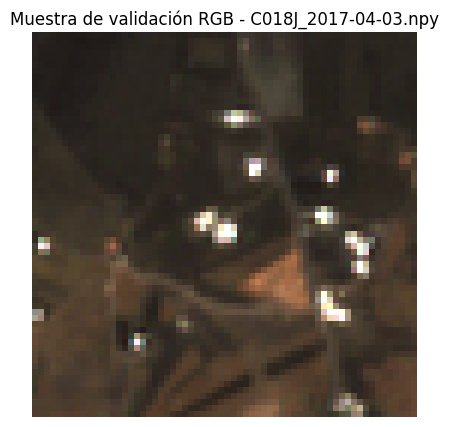

In [7]:
# listo los tensores descargados y selecciono el primero
archivos_npy = [f for f in os.listdir(RUTA_TENSORES) if f.endswith('.npy')]

if archivos_npy:
    archivo_muestra = archivos_npy[0]
    ruta_muestra = os.path.join(RUTA_TENSORES, archivo_muestra)

    # cargo la matriz a memoria
    tensor_muestra = np.load(ruta_muestra)

    print(f"tensor cargado: {archivo_muestra}")
    print(f"dimensiones matemáticas: {tensor_muestra.shape}")

    # separo los canales RGB (Rojo = índice 2, Verde = índice 1, Azul = índice 0)
    canal_r = tensor_muestra[:, :, 2]
    canal_g = tensor_muestra[:, :, 1]
    canal_b = tensor_muestra[:, :, 0]

    # apilo las matrices y normalizo la reflectancia para renderizar en color real
    imagen_color = np.dstack((canal_r, canal_g, canal_b))
    imagen_color = np.clip(imagen_color / 3000.0, 0, 1)

    # renderizo por pantalla
    plt.figure(figsize=(5, 5))
    plt.imshow(imagen_color)
    plt.title(f"Muestra de validación RGB - {archivo_muestra}")
    plt.axis('off')
    plt.show()

else:
    print("no hay tensores disponibles en el directorio especificado.")

Comprimimos los archivos generados para su posterior utilizacion, sin tener que volver a ejecutar el Cuaderno 1.

In [8]:
os.chdir('/content/drive/MyDrive/TFM_Riesgo_Incendios_Canarias')
!zip -rq dataset_tfm.zip dataset_meteo_satelite.csv catalogo_estaciones_canarias.csv tensores_satelite/